# Logisctic Regression

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [50]:
dataset = pd.read_csv('User_Data.csv')


In [51]:
x = dataset.iloc[:, [2,3]].values # input
y = dataset.iloc[:, 4].values # output


In [52]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.25, random_state=0)


In [53]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
xtrain = sc.fit_transform(xtrain)
xtest = sc.transform(xtest)

print(xtrain[0:10, :])


[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]]


In [54]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0)
classifier.fit(xtrain, ytrain)


LogisticRegression(random_state=0)

In [55]:
y_pred = classifier.predict(xtest)


In [56]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, y_pred)
print('Karışıklık Matrisi : \n', cm)


Karışıklık Matrisi : 
 [[65  3]
 [ 8 24]]


In [57]:
from sklearn.metrics import accuracy_score

print('Accuracy : ', accuracy_score(ytest, y_pred))


Accuracy :  0.89


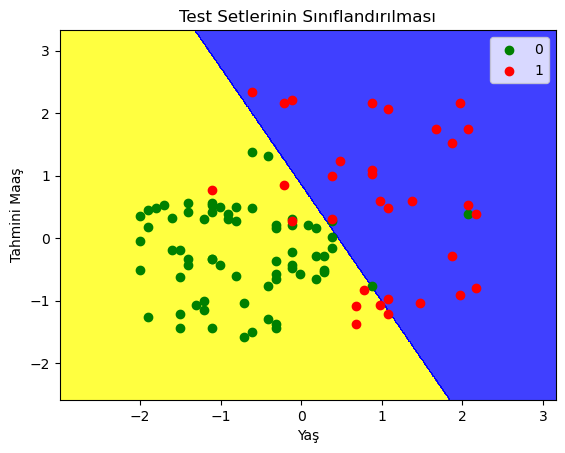

In [58]:
from matplotlib.colors import ListedColormap

X_set , y_set = xtest, ytest

# Karar sınırlarını çizmek için bir ağ oluşturun
X1, X2 = np.meshgrid(np.arange(start = xtest[:, 0].min() - 1,
							   stop = xtest[:, 0].max() + 1, step = 0.01),
					 np.arange(start = xtest[:, 1].min() - 1,
							   stop = xtest[:, 1].max() + 1, step = 0.01))

plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape), alpha=0.75, cmap=ListedColormap(('yellow', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i,j in enumerate(np.unique(y_set)):
	plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], color=ListedColormap(('green', 'red'))(i), label=j)

plt.title('Test Setlerinin Sınıflandırılması')
plt.xlabel('Yaş')
plt.ylabel('Tahmini Maaş')
plt.legend()
plt.show()
